[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/makankosappoh/Pytorch-Basics-Projects/blob/main/basics/ANN_CPU_GPU_optunahyperparamtune.ipynb)

#ANN ON CPU USING SAMPLE SUBSET OF FASHION MNSIT DATASET
---
AS WE WORKING ON CPU,HUGE DATASET WILL CAUSE TIME INEFFICIENCY AND HUGE LOAD SO WORKING WITH ONLY 6000 OUT OF 70 000 IMAGES WITH 4 NN LAYERS [784 FEATURES, 128 NERONS (RELU), 64 NEURONS (RELU), 10 NEURON OUTPUT (SOFTMAX)]

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
#upload file by right clicking.csv file and click upload to colab and choose kernel if working on vs code colab
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


/tmp/ipython-input-283096530.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]


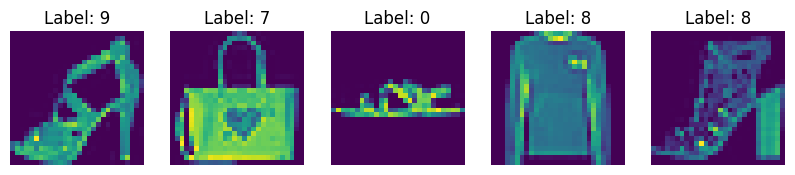

In [9]:
#random data vizulaize how the data looks like
import random
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    idx = random.randint(0, len(df)-1)
    row = df.iloc[idx]
    
    label = row[0]
    image = row[1:].values.reshape(28, 28)
    
    axes[i].imshow(image)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {df.iloc[i, 0]}")

plt.show()

In [10]:
#train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# scaling the feautures values between 0 and 1 
X_train = X_train/255.0
X_test = X_test/255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [11]:
# create CustomDataset Class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [12]:
#train and test dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

print(len(train_dataset), len(test_dataset))

4800 1200


In [13]:
#train and test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_dataloader), len(test_dataloader))

150 38


In [14]:
#Cretae sequential NN class
class ANNnn(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [15]:
epochs = 100
learning_rate = 0.001

# instatiate the model
model = ANNnn(X_train.shape[1])
# loss function
lossfxn = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [16]:
#training loop
# training loop

for epoch in range(epochs): 
    total_epoch_loss = 0
    for batch_features, batch_labels in train_dataloader:
        # forward pass
        outputs = model(batch_features)
        # calculate loss
        loss = lossfxn(outputs, batch_labels)
        # back pass
        optimizer.zero_grad()
        loss.backward()
        # update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_dataloader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 2.3027200222015383
Epoch: 2 , Loss: 2.288750384648641
Epoch: 3 , Loss: 2.2751428651809693
Epoch: 4 , Loss: 2.261805397669474
Epoch: 5 , Loss: 2.2476674938201904
Epoch: 6 , Loss: 2.2320830154418947
Epoch: 7 , Loss: 2.2145139598846435
Epoch: 8 , Loss: 2.1946947081883748
Epoch: 9 , Loss: 2.1725736061731973
Epoch: 10 , Loss: 2.148053766886393
Epoch: 11 , Loss: 2.120718879699707
Epoch: 12 , Loss: 2.090205348332723
Epoch: 13 , Loss: 2.0561222370465595
Epoch: 14 , Loss: 2.018382909297943
Epoch: 15 , Loss: 1.9769837911923727
Epoch: 16 , Loss: 1.93203249057134
Epoch: 17 , Loss: 1.8838531351089478
Epoch: 18 , Loss: 1.8332163619995117
Epoch: 19 , Loss: 1.780974768002828
Epoch: 20 , Loss: 1.7281179483731588
Epoch: 21 , Loss: 1.6755818947156271
Epoch: 22 , Loss: 1.6242455887794494
Epoch: 23 , Loss: 1.5747018957138061
Epoch: 24 , Loss: 1.5275002861022948
Epoch: 25 , Loss: 1.4826633175214132
Epoch: 26 , Loss: 1.44045317252477
Epoch: 27 , Loss: 1.4008608611424764
Epoch: 28 , Loss: 1.3

In [17]:
#evaluation
model.eval()

ANNnn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [18]:
#evaluation loop without libraries
with torch.inference_mode():
    test_loss, correct, total = 0, 0, 0
    for batch_features, batch_labels in test_dataloader:
        outputs = model(batch_features)
        loss = lossfxn(outputs, batch_labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
print(f'Test Loss: {test_loss/len(test_dataloader):.4f}, Test Accuracy: {correct/total:.4f}')

Test Loss: 0.7071, Test Accuracy: 0.7500


---

# NOW TRAINING ORIGINAL OPEN SOURCE DATA ON GPU WITH NEW STEPS 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


#check gpu availability
#step 1
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Using device: {device}')
torch.manual_seed(42)

Using device: cuda


In [ ]:
#this step is crucial as our dataset exceed colab limit of 120mb so we have to upload from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
#train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# scaling the feautures values between 0 and 1 
X_train = X_train/255.0
X_test = X_test/255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [10]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [11]:
#train and test dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

print(len(train_dataset), len(test_dataset))
#train and test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_dataloader), len(test_dataloader))

48000 12000
1500 375


In [13]:
#Cretae sequential NN class
class ANNnn(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
#step 2 DURING MDEL INSTANTIATION, LOSS FUNCTION AND OPTIMIZER CREATION
epochs = 100
learning_rate = 0.001

model = ANNnn(X_train.shape[1])
#HERE A NEW LINE - moving model to gpu
model.to(device)

lossfxn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [15]:
#step 3 IN TRAINING LOOP
for epoch in range(epochs): 
    total_epoch_loss = 0
    for batch_features, batch_labels in train_dataloader:
        
        #MOVE DATA TO GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        
        
        # forward pass
        outputs = model(batch_features)
        # calculate loss
        loss = lossfxn(outputs, batch_labels)
        # back pass
        optimizer.zero_grad()
        loss.backward()
        # update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_dataloader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 2.2352235374450684
Epoch: 2 , Loss: 1.9526607840855916
Epoch: 3 , Loss: 1.4877442998886108
Epoch: 4 , Loss: 1.1627141478061676
Epoch: 5 , Loss: 0.9813258058627446
Epoch: 6 , Loss: 0.8772625311215718
Epoch: 7 , Loss: 0.8119675739804904
Epoch: 8 , Loss: 0.7665024775266648
Epoch: 9 , Loss: 0.7308945667346318
Epoch: 10 , Loss: 0.7021114229957263
Epoch: 11 , Loss: 0.6768644301891327
Epoch: 12 , Loss: 0.6545582275787989
Epoch: 13 , Loss: 0.6349283828337987
Epoch: 14 , Loss: 0.6173683851559957
Epoch: 15 , Loss: 0.6015980908473333
Epoch: 16 , Loss: 0.5873084654708703
Epoch: 17 , Loss: 0.5745778130491574
Epoch: 18 , Loss: 0.5632152218023936
Epoch: 19 , Loss: 0.5530696668922901
Epoch: 20 , Loss: 0.543713372528553
Epoch: 21 , Loss: 0.5356239364941915
Epoch: 22 , Loss: 0.5277863224546114
Epoch: 23 , Loss: 0.5212709082265695
Epoch: 24 , Loss: 0.5150766234298547
Epoch: 25 , Loss: 0.5091424924135208
Epoch: 26 , Loss: 0.5038950842916965
Epoch: 27 , Loss: 0.4990943784713745
Epoch: 28 ,

In [16]:
model.eval()

ANNnn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
#STEP 4 IN EVALUATION LOOP

with torch.no_grad():
    test_loss, correct, total = 0, 0, 0
    for batch_features, batch_labels in test_dataloader:
        
        
        #MOVE DATA TO GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        
        outputs = model(batch_features)
        loss = lossfxn(outputs, batch_labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
print(f'Test Loss: {test_loss/len(test_dataloader):.4f}, Test Accuracy: {correct/total:.4f}')

Test Loss: 0.3974, Test Accuracy: 0.8594


HENCE ON GPU ACCURACY INCREASED FORM CPU - 75 TO GPU - 86

In [ ]:
##IF U WANT OT INCREASE GPU UTILIZATION, INCREASE BATCH SIZE
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

##also use of pin_memory_data_loader from torch.utils.data to speed up data loading if data is small enough to fit in memory
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

---

In [ ]:
#optimizing our code more

#DROPOUTS layers example
#dropout layers randomly set a fraction of input units to 0 at each update during training time, which helps prevent overfitting and improve generalization of the model.
class ANNnn(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            #here we add dropout layer with 0.2 dropout rate
            nn.Dropout(p = 0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)


#BATCH NORM LAYERS EXAMPLE
#Batch normalization layers normalize the activations of the previous layer for each mini-batch, which can help stabilize and accelerate the training process by reducing internal covariate shift.
class ANNnn(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            #here we add batch norm layer
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            #here we add batch norm layer
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

#REGULARIZATION EXAMPLE
#Regularization techniques, such as L1 or L2 regularization, add a penalty term to the loss function based on the magnitude of the model's weights, which can help prevent overfitting by encouraging the model to learn simpler patterns in the data.

optimizer = optim.SGD(model.parameters(), lr= learning_rate, weight_decay=0.01 or 1e-4)

# HYPERPARAM TUNING USING OPTUNA

we can do using grid search cv
random search cv
but 
a special one is called BAYESIAN SEARCH very optimized in new gen used by OPTUNA 

#bayesian search creates a fxn between 
accuracy = fxn(n_estimator and max depth) == easy maxima search using graphical approach

#KEY TERMS BEFORE STUDYING OPTUNA

#Study: An Optuna Study is an optimization task that consists of multiple trials. It manages the optimization process, including the storage of trial results and the selection of hyperparameters for each trial. example study to find best parameter tune for xgboost

#Trial: A Trial represents a single execution of the objective function with a specific set of hyperparameters. Each trial evaluates the performance of the model with those hyperparameters and returns a result (e.g., validation loss or accuracy) that Optuna uses to guide the optimization process.example one trial involve mdoel training with lr = 001 and another trial involve model training with lr = 0.01 and then comparing the results to find the best learning rate for our model.

#trial parameter: Trial parameters are the specific hyperparameters that are being optimized in each trial. example in above we choose learning rate as trial parameter and then we compare the results of different learning rates to find the best one for our model.

#objective function: An objective function is a user-defined function that Optuna seeks to minimize or maximize during the optimization process. It takes a set of hyperparameters as input and returns a scalar value representing the performance of the model with those hyperparameters. example objective function for xgboost could be defined to train the model with given hyperparameters and return the validation loss or accuracy as the output, which Optuna will use to evaluate and compare different sets of hyperparameters during the optimization process.

#sampler is a strategy for selecting the hyperparameters to evaluate in each trial. optuna uses TPE(tree-structured Parzen Estimator) sampler by default, which is a Bayesian optimization method that models the relationship between hyperparameters and the objective function to efficiently explore the hyperparameter space. example TPE sampler will select hyperparameters based on past trial results, focusing on promising regions of the hyperparameter space to find optimal configurations more quickly.

In [22]:
#example of OPTUNA FRAMEWORK FOR HYPERPARAMETER TUNING
!pip install optuna
import optuna
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#Import samplers
from optuna.samplers import TPESampler, RandomSampler

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Objective function
def objective(trial):
    svc_c = trial.suggest_float('C', 1e-10, 1e10, log=True)
    svc_gamma = trial.suggest_float('gamma', 1e-10, 1e10, log=True)
    
    clf = SVC(C=svc_c, gamma=svc_gamma)
    
    score = cross_val_score(clf, X, y, n_jobs=-1, cv=3).mean()
    return score

# ✅ Choose a sampler
sampler = TPESampler(seed=42)   # Best general-purpose sampler
# sampler = RandomSampler(seed=42)  # Pure random search (optional)

# Create study with sampler
study = optuna.create_study(direction='maximize', sampler=sampler)

# Optimize
study.optimize(objective, n_trials=100)

# Results
print('Best hyperparameters:', study.best_params)
print('Best performance:', study.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.1 MB/s eta 0:00:0000:01


[I 2026-03-22 13:45:14,803] A new study created in memory with name: no-name-580c26de-9142-4b20-9b5d-6445810d1992
[I 2026-03-22 13:45:18,501] Trial 0 finished with value: 0.32 and parameters: {'C': 0.0030960101581081526, 'gamma': 1033442048.8216696}. Best is trial 0 with value: 0.32.
[I 2026-03-22 13:45:18,552] Trial 1 finished with value: 0.6066666666666667 and parameters: {'C': 43639.40657205739, 'gamma': 94.00905432049124}. Best is trial 1 with value: 0.6066666666666667.
[I 2026-03-22 13:45:18,596] Trial 2 finished with value: 0.32 and parameters: {'C': 1.3193888477530263e-07, 'gamma': 1.3179241212806612e-07}. Best is trial 1 with value: 0.6066666666666667.
[I 2026-03-22 13:45:18,629] Trial 3 finished with value: 0.32 and parameters: {'C': 1.4510161404606145e-09, 'gamma': 21063130.35425753}. Best is trial 1 with value: 0.6066666666666667.
[I 2026-03-22 13:45:18,657] Trial 4 finished with value: 0.32666666666666666 and parameters: {'C': 105.26893636712298, 'gamma': 14502.789915706271

Best hyperparameters: {'C': 141104.23558700335, 'gamma': 5.550505373369429e-06}
Best performance: 0.9933333333333333


---

# Back to our CODE GPU with new code 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


#check gpu availability
#step 1
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Using device: {device}')
torch.manual_seed(42)

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/fashion-mnist_train.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# scaling the feautures values between 0 and 1 
X_train = X_train/255.0
X_test = X_test/255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((48000, 784), (48000,), (12000, 784), (12000,))

In [4]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        # Convert to PyTorch tensors
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [5]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [6]:
#new NN code based on objective function for optuna changes are number of hidden layers, neurons per layer, dropout rate, batch size, optimizer and weight decay
class MyNN(nn.Module):
    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

        super().__init__()
        layers = []

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = neurons_per_layer
        layers.append(nn.Linear(neurons_per_layer, output_dim))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

In [7]:
# objective function
def objective(trial):
    # hyperparameters
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    
    #training dataloaders is moved inside the objective function to ensure that it is recreated for each trial with the new batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # model
    input_dim = 784
    output_dim = 10
    model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
    model.to(device)

    # loss and optimizer
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # training
    for epoch in range(epochs):
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)

            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = correct / total
    return accuracy

In [8]:
!pip install optuna
import optuna
study = optuna.create_study(direction="maximize")

[I 2026-03-22 14:16:04,152] A new study created in memory with name: no-name-3c205fb1-17d0-4c68-8b42-5888c9a90f91


In [9]:
#more the trial more the chances of finding better hyperparameters but it will take more time to run
study.optimize(objective, n_trials=10)

[I 2026-03-22 14:18:07,628] Trial 0 finished with value: 0.6266666666666667 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 24, 'epochs': 50, 'learning_rate': 1.3645100896980634e-05, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 6.40514641297045e-05}. Best is trial 0 with value: 0.6266666666666667.
[I 2026-03-22 14:19:48,432] Trial 1 finished with value: 0.7758333333333334 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 64, 'epochs': 50, 'learning_rate': 0.00021513170319786655, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 3.6309645912074295e-05}. Best is trial 1 with value: 0.7758333333333334.
[I 2026-03-22 14:22:10,363] Trial 2 finished with value: 0.8426666666666667 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 128, 'epochs': 40, 'learning_rate': 0.00040038486293554745, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.0001

In [10]:
print(study.best_value)
print(study.best_params)

0.8799166666666667
{'num_hidden_layers': 1, 'neurons_per_layer': 128, 'epochs': 50, 'learning_rate': 0.0021879307018994975, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00018230749139263894}
